In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix


In [2]:
uncleaned_data = pd.read_csv("Data01.csv")
uncleaned_data.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
uncleaned_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
uncleaned_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Gender,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
uncleaned_data.shape

(891, 12)

In [6]:
uncleaned_data["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [8]:
df = uncleaned_data[["Pclass", 'Gender', 'Age', 'SibSp', 'Parch', 'Fare','Embarked', "Survived"]].copy()

In [9]:
df.head()

,Pclass,Gender,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


<Axes: xlabel='Embarked', ylabel='Count'>

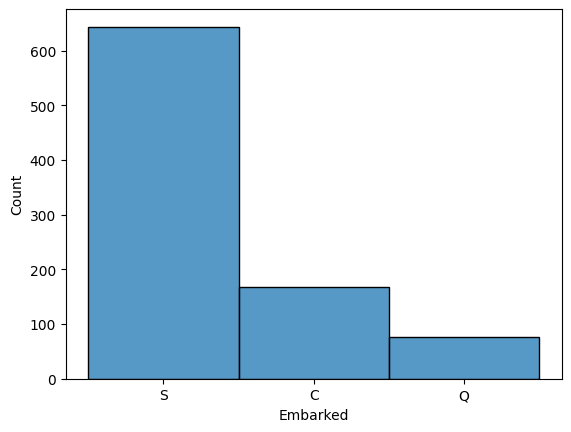

In [12]:
sns.histplot(x=df["Embarked"])

Since, the "Embarked" data has most of "S" values. Therefore, I am filling 2 null values of columns "Embarked" with "S".

In [15]:
df["Embarked"] = df["Embarked"].fillna("S")

In [16]:
df.isnull().sum()

,0
Pclass,0
Gender,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,0
Survived,0


<Axes: xlabel='Age', ylabel='Count'>

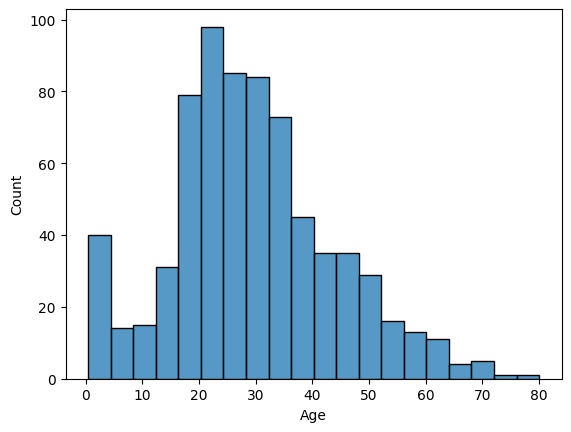

In [19]:
sns.histplot(x=df["Age"])

In [20]:
df["Age"].skew()

np.float64(0.38910778230082704)

The columns "Age" is nearly normally distributed. That's why, I am using mean value in this column.

In [21]:
from math import floor
df["Age"] = df["Age"].fillna(floor(df["Age"].mean()))

In [22]:
df

,Pclass,Gender,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,0
887,1,female,19.0,0,0,30.0000,S,1
888,3,female,29.0,1,2,23.4500,S,0
889,1,male,26.0,0,0,30.0000,C,1


In [24]:
df.isnull().sum()

,0
Pclass,0
Gender,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Survived,0


In [27]:
df = pd.get_dummies(df, columns=["Gender"], prefix="Sex")
df.head()

,Pclass,Age,SibSp,Parch,Fare,Embarked,Survived,Sex_female,Sex_male
0,3,22.0,1,0,7.2500,S,0,False,True
1,1,38.0,1,0,71.2833,C,1,True,False
2,3,26.0,0,0,7.9250,S,1,True,False
3,1,35.0,1,0,53.1000,S,1,True,False
4,3,35.0,0,0,8.0500,S,0,False,True
